In [ ]:
!pip install wfdb -q

In [3]:
import wfdb

wfdb.dl_database('mitdb', dl_dir='mitdb', records=['100'])

Generating record list for: 100
Generating list of all files for: 100
Created local base download directory: mitdb
Finished downloading files


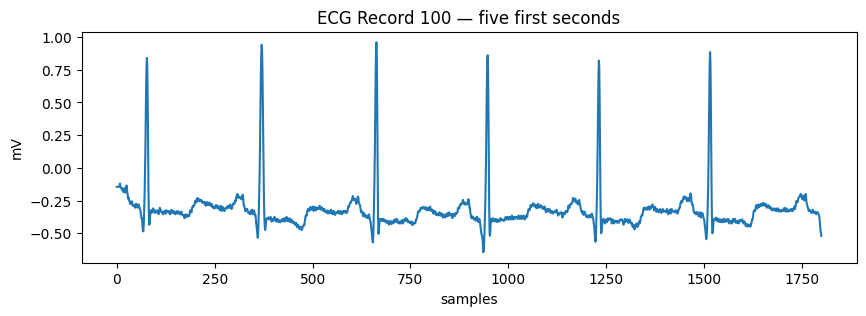

In [9]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('mitdb/100')
signal = record.p_signal[:1800, 0]  # 5 first secoconds(360Hz * 5)

plt.figure(figsize=(10, 3))
plt.plot(signal)
plt.title("ECG Record 100 — five first seconds")
plt.xlabel("samples")
plt.ylabel("mV")
plt.show()

In [5]:
# List of all 48 MIT-BIH Arrhythmia Database records
all_records = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

wfdb.dl_database('mitdb', dl_dir='mitdb', records=all_records)
print("Download complete.")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [6]:
import os
import pandas as pd

# AAMI mapping: original MIT-BIH annotation symbol -> final class
aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
}
excluded_symbols = {'/', 'f', 'Q'}  # paced / unclassifiable beats

rows = []
for rec in all_records:
    ann = wfdb.rdann(os.path.join('mitdb', rec), 'atr')
    for sample, sym in zip(ann.sample, ann.symbol):
        if sym in aami_map:
            final_class = aami_map[sym]
        elif sym in excluded_symbols:
            final_class = 'EXCLUDED'
        else:
            final_class = 'OTHER'  # non-beat annotations (rhythm markers etc.)
        rows.append({'record': rec, 'sample': sample, 'symbol': sym, 'final_class': final_class})

beats = pd.DataFrame(rows)
print(f"Total annotations: {len(beats)}")
beats.head()

Total annotations: 112647


,record,sample,symbol,final_class
0,100,18,+,OTHER
1,100,77,N,N
2,100,370,N,N
3,100,662,N,N
4,100,946,N,N


In [8]:
class_counts = beats[beats['final_class'].isin(['N', 'S', 'V', 'F'])].groupby('final_class').size()
print(class_counts)

final_class
F      803
N    90631
S     2781
V     7236
dtype: int64


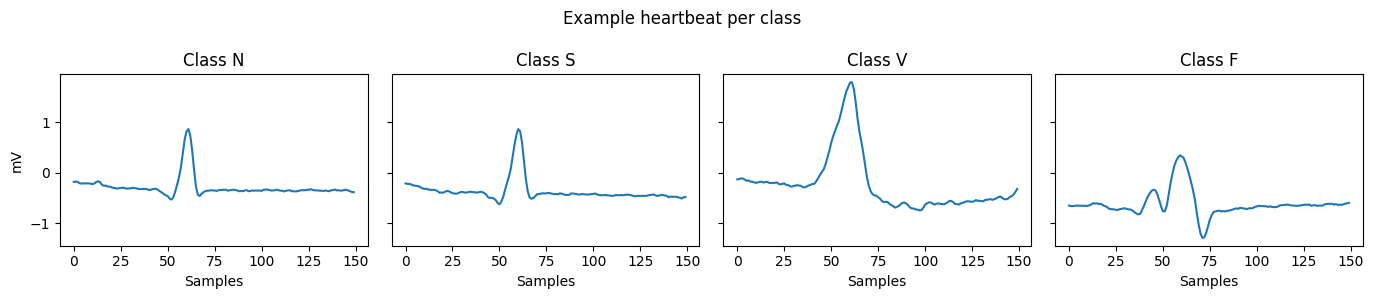

In [12]:
import numpy as np

# Plot one example heartbeat for each class (N, S, V, F)
window_before = 60   # samples before the R-peak (~0.25s at 360Hz)
window_after = 90   # samples after the R-peak

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for ax, cls in zip(axes, ['N', 'S', 'V', 'F']):
    # pick one example beat of this class
    example = beats[beats['final_class'] == cls].iloc[10]
    rec = wfdb.rdrecord(f"mitdb/{example['record']}")
    center = int(example['sample'])
    beat_signal = rec.p_signal[center - window_before : center + window_after, 0]

    ax.plot(beat_signal)
    ax.set_title(f"Class {cls}")
    ax.set_xlabel("Samples")

axes[0].set_ylabel("mV")
plt.suptitle("Example heartbeat per class")
plt.tight_layout()
plt.show()

In [13]:
# Check minimum distance between consecutive beat annotations, per record
# This tells us whether our 200-sample window risks overlapping the next beat

min_distances = []

for rec in all_records:
    rec_beats = beats[(beats['record'] == rec) & (beats['final_class'].isin(['N','S','V','F']))]
    samples_sorted = rec_beats['sample'].sort_values().values
    if len(samples_sorted) > 1:
        diffs = np.diff(samples_sorted)
        min_distances.append(diffs.min())

min_distances = np.array(min_distances)
print(f"Smallest gap between two consecutive beats (across all records): {min_distances.min()} samples")
print(f"Number of records with a gap smaller than 150 samples: {(min_distances < 150).sum()} out of {len(min_distances)}")

Smallest gap between two consecutive beats (across all records): 90 samples
Number of records with a gap smaller than 150 samples: 20 out of 48


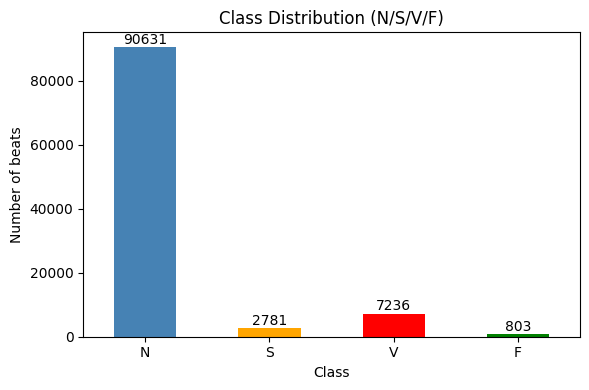

In [14]:
# Class distribution bar chart (Section 2.3 EDA)
class_counts = beats[beats['final_class'].isin(['N', 'S', 'V', 'F'])].groupby('final_class').size()
class_counts = class_counts.reindex(['N', 'S', 'V', 'F'])  # keep consistent order

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['steelblue', 'orange', 'red', 'green'])
plt.title("Class Distribution (N/S/V/F)")
plt.xlabel("Class")
plt.ylabel("Number of beats")
plt.xticks(rotation=0)

# add exact counts on top of each bar
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 1000, str(v), ha='center')

plt.tight_layout()
plt.show()

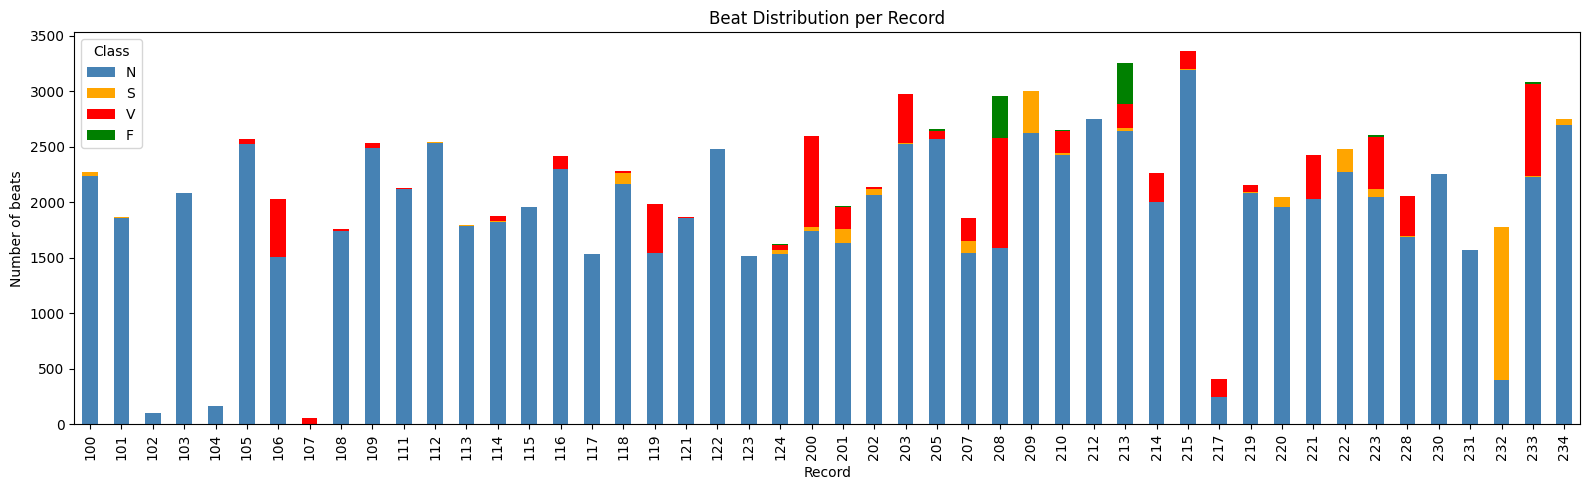

In [15]:
# Beat distribution per record (Section 2.3 EDA)
beat_df = beats[beats['final_class'].isin(['N', 'S', 'V', 'F'])]
per_record = beat_df.pivot_table(index='record', columns='final_class',
                                   values='sample', aggfunc='count', fill_value=0)
per_record = per_record[['N', 'S', 'V', 'F']]  # consistent column order

per_record.plot(kind='bar', stacked=True, figsize=(16, 5),
                 color=['steelblue', 'orange', 'red', 'green'])
plt.title("Beat Distribution per Record")
plt.xlabel("Record")
plt.ylabel("Number of beats")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

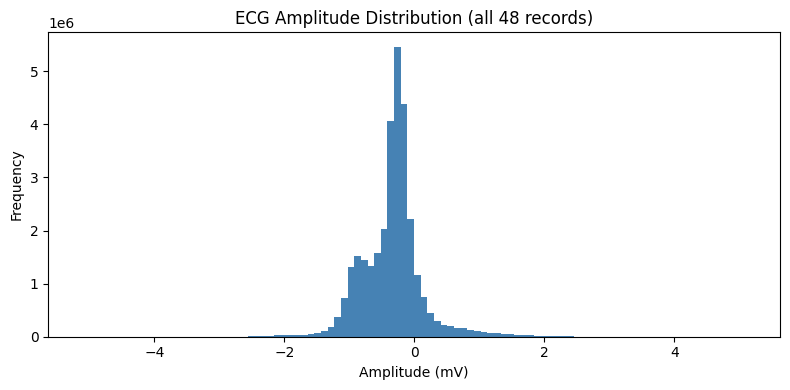

Min amplitude: -5.120 mV
Max amplitude: 5.115 mV
Mean: -0.339 mV, Std: 0.472 mV


In [16]:
all_amplitudes = []

for rec in all_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    all_amplitudes.append(r.p_signal[:, 0])

all_amplitudes = np.concatenate(all_amplitudes)

plt.figure(figsize=(8, 4))
plt.hist(all_amplitudes, bins=100, color='steelblue')
plt.title("ECG Amplitude Distribution (all 48 records)")
plt.xlabel("Amplitude (mV)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Min amplitude: {all_amplitudes.min():.3f} mV")
print(f"Max amplitude: {all_amplitudes.max():.3f} mV")
print(f"Mean: {all_amplitudes.mean():.3f} mV, Std: {all_amplitudes.std():.3f} mV")

In [17]:
# Check for missing/NaN values across all records (Section 2.4 Data Quality)
missing_report = []

for rec in all_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    n_nan = np.isnan(r.p_signal).sum()
    missing_report.append({'record': rec, 'nan_count': n_nan, 'total_samples': r.p_signal.size})

missing_df = pd.DataFrame(missing_report)
print(f"Total NaN values across all records: {missing_df['nan_count'].sum()}")
print(f"Records with missing data: {(missing_df['nan_count'] > 0).sum()} out of {len(missing_df)}")

Total NaN values across all records: 0
Records with missing data: 0 out of 48


In [18]:
# Check for extreme amplitude values across all records (Section 2.4 Data Quality)
threshold = 4.0  # mV — values beyond this are considered extreme/suspicious

extreme_report = []

for rec in all_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    sig = r.p_signal[:, 0]
    n_extreme = (np.abs(sig) > threshold).sum()
    extreme_report.append({'record': rec, 'extreme_count': n_extreme, 'pct': 100 * n_extreme / len(sig)})

extreme_df = pd.DataFrame(extreme_report)
print(f"Total extreme samples (|amplitude| > {threshold} mV): {extreme_df['extreme_count'].sum()}")
print(f"Records with at least one extreme sample: {(extreme_df['extreme_count'] > 0).sum()} out of {len(extreme_df)}")
print("\nTop 5 records with most extreme values:")
print(extreme_df.sort_values('extreme_count', ascending=False).head())

Total extreme samples (|amplitude| > 4.0 mV): 1986
Records with at least one extreme sample: 3 out of 48

Top 5 records with most extreme values:
   record  extreme_count       pct
15    116           1720  0.264615
19    121            234  0.036000
26    203             32  0.004923
0     100              0  0.000000
4     104              0  0.000000


In [19]:
# Check which ECG lead (channel) each record uses (Section 2.4 Data Quality)
lead_report = []

for rec in all_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    lead_report.append({'record': rec, 'channels': r.sig_name})

lead_df = pd.DataFrame(lead_report)
print(lead_df)

# Count how many records have each lead in channel 0
print("\nChannel 0 lead counts:")
print(lead_df['channels'].apply(lambda x: x[0]).value_counts())

   record    channels
0     100  [MLII, V5]
1     101  [MLII, V1]
2     102    [V5, V2]
3     103  [MLII, V2]
4     104    [V5, V2]
5     105  [MLII, V1]
6     106  [MLII, V1]
7     107  [MLII, V1]
8     108  [MLII, V1]
9     109  [MLII, V1]
10    111  [MLII, V1]
11    112  [MLII, V1]
12    113  [MLII, V1]
13    114  [V5, MLII]
14    115  [MLII, V1]
15    116  [MLII, V1]
16    117  [MLII, V2]
17    118  [MLII, V1]
18    119  [MLII, V1]
19    121  [MLII, V1]
20    122  [MLII, V1]
21    123  [MLII, V5]
22    124  [MLII, V4]
23    200  [MLII, V1]
24    201  [MLII, V1]
25    202  [MLII, V1]
26    203  [MLII, V1]
27    205  [MLII, V1]
28    207  [MLII, V1]
29    208  [MLII, V1]
30    209  [MLII, V1]
31    210  [MLII, V1]
32    212  [MLII, V1]
33    213  [MLII, V1]
34    214  [MLII, V1]
35    215  [MLII, V1]
36    217  [MLII, V1]
37    219  [MLII, V1]
38    220  [MLII, V1]
39    221  [MLII, V1]
40    222  [MLII, V1]
41    223  [MLII, V1]
42    228  [MLII, V1]
43    230  [MLII, V1]
44    231 

In [23]:
DS1 = ['101','106','108','109','112','114','115','116','118','119',
       '122','124','201','203','205','207','208','209','215','220',
       '223','230']

DS2 = ['100','103','105','111','113','117','121','123','200','202',
       '210','212','213','214','219','221','222','228','231','232',
       '233','234']

In [24]:
# Identify records that do NOT have MLII as their primary lead (Section 3.2)
non_mlii_records = lead_df[lead_df['channels'].apply(lambda x: x[0] != 'MLII')]['record'].tolist()
print(f"Records without MLII as channel 0: {non_mlii_records}")

# Final list of usable records (MLII only)
usable_records = [r for r in all_records if r not in non_mlii_records]
print(f"\nUsable records (MLII only): {len(usable_records)} out of {len(all_records)}")

# Updated DS1 / DS2 lists after excluding non-MLII records
ds1_final = [r for r in DS1 if r in usable_records]
ds2_final = [r for r in DS2 if r in usable_records]
print(f"\nDS1 (train/val) after exclusion: {len(ds1_final)} records")
print(f"DS2 (test) after exclusion: {len(ds2_final)} records")
print(f"Excluded from DS1: {[r for r in DS1 if r not in usable_records]}")
print(f"Excluded from DS2: {[r for r in DS2 if r not in usable_records]}")

Records without MLII as channel 0: ['102', '104', '114']

Usable records (MLII only): 45 out of 48

DS1 (train/val) after exclusion: 21 records
DS2 (test) after exclusion: 22 records
Excluded from DS1: ['114']
Excluded from DS2: []


In [25]:
# 3.3 Beat Extraction — build fixed-size beat segments for all usable records
window_before = 60
window_after = 90
window_size = window_before + window_after  # 150 samples total

X = []       # beat signal segments
y = []       # class labels
record_ids = []  # which record each beat came from (needed later for splitting)

for rec in usable_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    signal = r.p_signal[:, 0]  # MLII channel
    rec_beats = beats[(beats['record'] == rec) & (beats['final_class'].isin(['N','S','V','F']))]

    for _, row in rec_beats.iterrows():
        center = int(row['sample'])
        start, end = center - window_before, center + window_after
        # skip beats too close to the start/end of the recording
        if start < 0 or end > len(signal):
            continue
        segment = signal[start:end]
        X.append(segment)
        y.append(row['final_class'])
        record_ids.append(rec)

X = np.array(X)
y = np.array(y)
record_ids = np.array(record_ids)

print(f"Total extracted beats: {len(X)}")
print(f"Segment shape: {X.shape}")
print(f"Class distribution: {pd.Series(y).value_counts()}")

Total extracted beats: 99286
Segment shape: (99286, 150)
Class distribution: N    88533
V     7186
S     2769
F      798
Name: count, dtype: int64


Before normalization -> mean: -0.319, std: 0.537
After normalization  -> mean: -0.000, std: 1.000


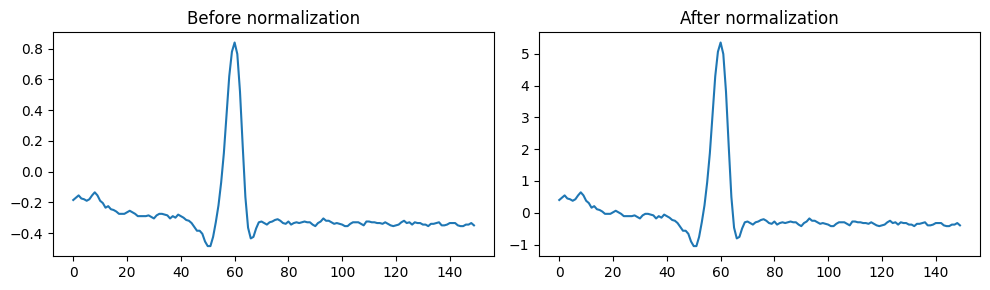

In [26]:
# 3.4 Signal Preprocessing — per-beat z-score normalization
# Each beat segment is normalized independently: subtract its own mean, divide by its own std.
# This removes baseline offset differences between beats/records/patients.

X_normalized = np.zeros_like(X)

for i in range(len(X)):
    seg = X[i]
    mean = seg.mean()
    std = seg.std()
    X_normalized[i] = (seg - mean) / (std + 1e-8)  # 1e-8 avoids division by zero

print(f"Before normalization -> mean: {X.mean():.3f}, std: {X.std():.3f}")
print(f"After normalization  -> mean: {X_normalized.mean():.3f}, std: {X_normalized.std():.3f}")

# Quick visual check: same beat, before vs after
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(X[0])
plt.title("Before normalization")
plt.subplot(1, 2, 2)
plt.plot(X_normalized[0])
plt.title("After normalization")
plt.tight_layout()
plt.show()

Total beats after filtering: 99286


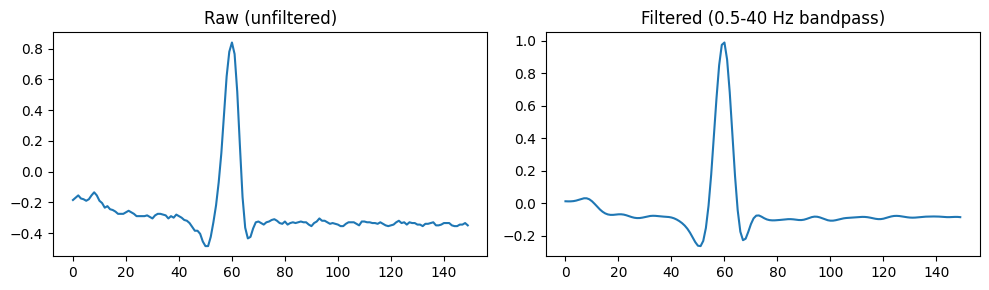

In [27]:
from scipy.signal import butter, filtfilt

# 3.4 Signal Preprocessing — bandpass filter (0.5-40 Hz), applied to the full
# signal BEFORE beat extraction, to remove baseline wander and high-frequency noise.

def bandpass_filter(signal, fs=360, lowcut=0.5, highcut=40, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

# Rebuild X using filtered signals
X_filtered = []
y_filtered = []
record_ids_filtered = []

for rec in usable_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    raw_signal = r.p_signal[:, 0]
    filtered_signal = bandpass_filter(raw_signal)  # filter the WHOLE record first

    rec_beats = beats[(beats['record'] == rec) & (beats['final_class'].isin(['N','S','V','F']))]
    for _, row in rec_beats.iterrows():
        center = int(row['sample'])
        start, end = center - window_before, center + window_after
        if start < 0 or end > len(filtered_signal):
            continue
        segment = filtered_signal[start:end]
        X_filtered.append(segment)
        y_filtered.append(row['final_class'])
        record_ids_filtered.append(rec)

X_filtered = np.array(X_filtered)
y_filtered = np.array(y_filtered)
record_ids_filtered = np.array(record_ids_filtered)

print(f"Total beats after filtering: {len(X_filtered)}")

# Visual comparison: same beat, raw vs filtered
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(X[0])
plt.title("Raw (unfiltered)")
plt.subplot(1, 2, 2)
plt.plot(X_filtered[0])
plt.title("Filtered (0.5-40 Hz bandpass)")
plt.tight_layout()
plt.show()

Final dataset shape: (99286, 150)
Mean: -0.000, Std: 1.000


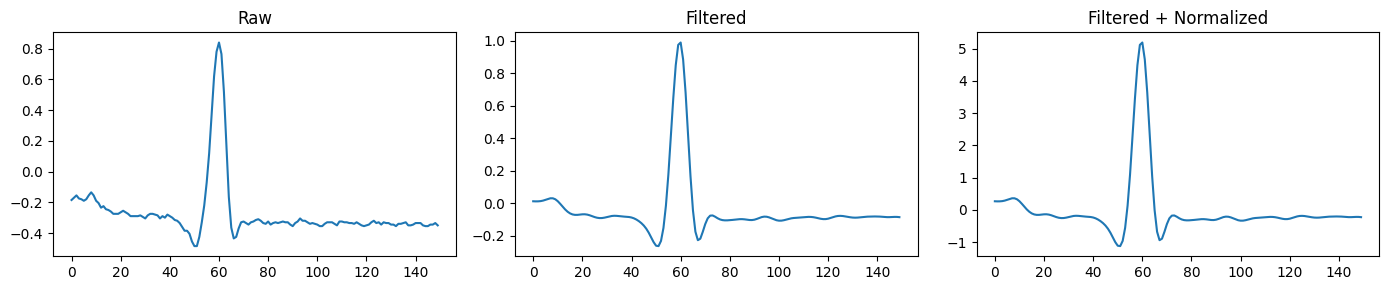

In [28]:
# Final preprocessing: normalize the FILTERED beats (correct order: filter -> normalize)
X_final = np.zeros_like(X_filtered)

for i in range(len(X_filtered)):
    seg = X_filtered[i]
    mean = seg.mean()
    std = seg.std()
    X_final[i] = (seg - mean) / (std + 1e-8)

y_final = y_filtered
record_ids_final = record_ids_filtered

print(f"Final dataset shape: {X_final.shape}")
print(f"Mean: {X_final.mean():.3f}, Std: {X_final.std():.3f}")

# Visual: raw -> filtered -> filtered+normalized, same beat
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=False)
axes[0].plot(X[0]); axes[0].set_title("Raw")
axes[1].plot(X_filtered[0]); axes[1].set_title("Filtered")
axes[2].plot(X_final[0]); axes[2].set_title("Filtered + Normalized")
plt.tight_layout()
plt.show()

In [29]:
# 3.6 Class Imbalance — compute class weights (inverse frequency)
from collections import Counter

class_counts_final = Counter(y_final)
total = sum(class_counts_final.values())
n_classes = len(class_counts_final)

# Standard formula: weight = total_samples / (n_classes * count_of_class)
class_weights = {cls: total / (n_classes * count) for cls, count in class_counts_final.items()}

print("Class counts:", dict(class_counts_final))
print("\nClass weights:")
for cls, w in sorted(class_weights.items()):
    print(f"  {cls}: {w:.3f}")

Class counts: {np.str_('N'): 88533, np.str_('S'): 2769, np.str_('V'): 7186, np.str_('F'): 798}

Class weights:
  F: 31.105
  N: 0.280
  S: 8.964
  V: 3.454


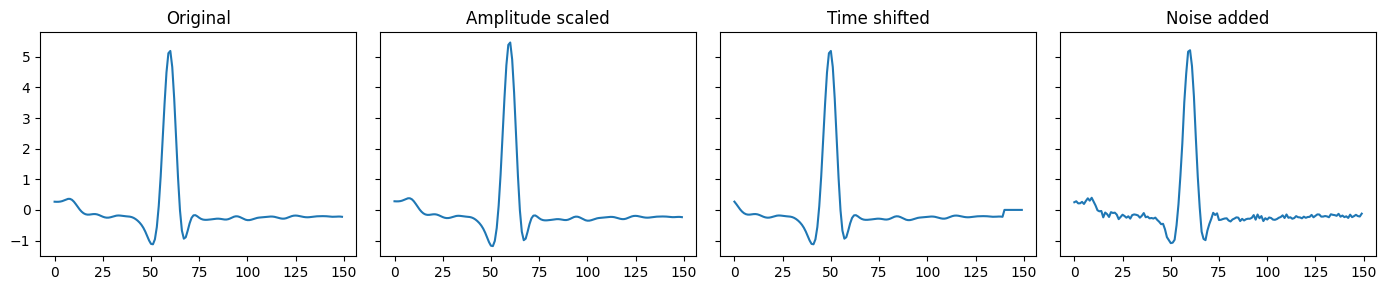

In [31]:
# 3.7 Data Augmentation — define augmentation functions (applied ONLY to training data, later)

def augment_amplitude_scale(signal, scale_range=(0.9, 1.1)):
    """Randomly scale the amplitude of the beat."""
    scale = np.random.uniform(*scale_range)
    return signal * scale

def augment_time_shift(signal, max_shift=10):
    """Randomly shift the beat left/right by a few samples (zero-padded, not wrapped)."""
    shift = np.random.randint(-max_shift, max_shift + 1)
    shifted = np.zeros_like(signal)
    if shift > 0:
        shifted[shift:] = signal[:-shift]
    elif shift < 0:
        shifted[:shift] = signal[-shift:]
    else:
        shifted = signal.copy()
    return shifted

def augment_add_noise(signal, noise_std=0.05):
    """Add small Gaussian noise to simulate sensor/measurement noise."""
    noise = np.random.normal(0, noise_std, size=signal.shape)
    return signal + noise

# Visual demonstration on one example beat
example_beat = X_final[0]

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
axes[0].plot(example_beat); axes[0].set_title("Original")
axes[1].plot(augment_amplitude_scale(example_beat)); axes[1].set_title("Amplitude scaled")
axes[2].plot(augment_time_shift(example_beat)); axes[2].set_title("Time shifted")
axes[3].plot(augment_add_noise(example_beat)); axes[3].set_title("Noise added")
plt.tight_layout()
plt.show()

In [32]:
# 3.8 Final Dataset — split into Train / Validation / Test (by record, not by beat)
import random

random.seed(42)  # reproducibility (Section 3.9)

# DS1 records -> split into train (80%) and validation (20%) by record
ds1_records = list(ds1_final)
random.shuffle(ds1_records)
n_val = max(1, int(0.2 * len(ds1_records)))
val_records = ds1_records[:n_val]
train_records = ds1_records[n_val:]

test_records = ds2_final  # DS2, untouched

print(f"Train records ({len(train_records)}): {train_records}")
print(f"Validation records ({len(val_records)}): {val_records}")
print(f"Test records ({len(test_records)}): {test_records}")

# Build boolean masks based on record_ids_final
train_mask = np.isin(record_ids_final, train_records)
val_mask = np.isin(record_ids_final, val_records)
test_mask = np.isin(record_ids_final, test_records)

X_train, y_train = X_final[train_mask], y_final[train_mask]
X_val, y_val = X_final[val_mask], y_final[val_mask]
X_test, y_test = X_final[test_mask], y_final[test_mask]

print(f"\nTrain set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Train records (17): ['122', '205', '208', '220', '116', '203', '215', '124', '106', '201', '108', '209', '118', '119', '101', '109', '230']
Validation records (4): ['223', '115', '207', '112']
Test records (22): ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']

Train set: (40172, 150), Validation set: (8955, 150), Test set: (49694, 150)


In [33]:
# Table 3.8 — class distribution per split
def class_dist(y_array, name):
    counts = pd.Series(y_array).value_counts().reindex(['N', 'S', 'V', 'F']).fillna(0).astype(int)
    counts['Total'] = counts.sum()
    counts.name = name
    return counts

table_3_8 = pd.concat([
    class_dist(y_train, 'Train'),
    class_dist(y_val, 'Validation'),
    class_dist(y_test, 'Test')
], axis=1).T

print(table_3_8)

                N     S     V    F  Total
Train       35964   750  3062  396  40172
Validation   8076   182   683   14   8955
Test        44249  1837  3220  388  49694


In [34]:
# Check F-beat counts per DS1 record, to choose a validation set with better F representation
ds1_f_counts = beats[(beats['record'].isin(ds1_final)) & (beats['final_class'] == 'F')] \
                    .groupby('record').size().sort_values(ascending=False)
print("F-beat counts per DS1 record (sorted):")
print(ds1_f_counts)

F-beat counts per DS1 record (sorted):
record
208    373
223     14
205     11
124      5
108      2
109      2
201      2
203      1
215      1
dtype: int64


In [35]:
# Manually choose validation records to ensure reasonable F representation
val_records = ['223', '205', '124', '109']  # good F counts + reasonable total size
train_records = [r for r in ds1_final if r not in val_records]

print(f"Train records ({len(train_records)}): {train_records}")
print(f"Validation records ({len(val_records)}): {val_records}")

train_mask = np.isin(record_ids_final, train_records)
val_mask = np.isin(record_ids_final, val_records)
test_mask = np.isin(record_ids_final, test_records)

X_train, y_train = X_final[train_mask], y_final[train_mask]
X_val, y_val = X_final[val_mask], y_final[val_mask]
X_test, y_test = X_final[test_mask], y_final[test_mask]

table_3_8 = pd.concat([
    class_dist(y_train, 'Train'),
    class_dist(y_val, 'Validation'),
    class_dist(y_test, 'Test')
], axis=1).T
print("\n", table_3_8)

Train records (17): ['101', '106', '108', '112', '115', '116', '118', '119', '122', '201', '203', '207', '208', '209', '215', '220', '230']
Validation records (4): ['223', '205', '124', '109']

                 N     S     V    F  Total
Train       35397   825  3116  378  39716
Validation   8643   107   629   32   9411
Test        44249  1837  3220  388  49694


In [36]:
# 3.9 Reproducibility — check software versions
import sys
import wfdb, numpy, pandas, scipy, matplotlib

print(f"Python: {sys.version}")
print(f"wfdb: {wfdb.__version__}")
print(f"numpy: {numpy.__version__}")
print(f"pandas: {pandas.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
wfdb: 4.3.1
numpy: 2.1.3
pandas: 2.2.3
scipy: 1.16.3
matplotlib: 3.10.0
